# Testing a unified GRB + afterglow model

An issue was found when I was reading the code for the unified GRB + afterglow model. We assumed that the GRB saturated directly and the afterglow rised during a time of T90. However, I think it is wrong. The GRB should saturate during a time of T90, and the afterglow should start to rise at a latter time and different timescale. Here I review the code and try to implement this change. I also want to test the model with some parameters and see how it behaves.

## Model for the GRB 

A simple model for the GRB would be a function that rises to a maximum value (saturation) during a time T90 and then saturates:
$$\Delta h_{\rm GRB}(t) = \begin{cases}
0 & \text{if } t < 0 \\
\Delta h_{\text{GRB}} \cdot \frac{t}{T_{90}} & \text{if } 0 \le t < T_{90} \\
\Delta h_{\text{GRB}} & \text{if } t \geq T_{90}
\end{cases}$$

## Model for the Afterglow

Here is the major correction. The afterglow should start to rise at a latter time and different timescale. 

I could use two different timescales to define:
1. The time when the afterglow starts to rise, which allow an afterglow emission to start before or after $T_{90}$ .
2. The timescale for the afterglow rise, which could be defined as the total duration of the afterglow or the time just before it reaches its maximum value - before the decay phase starts. The latter is more physical in the context of memory effect, as it represents the time when the afterglow is still rising and contributing to the memory effect (and so deposing energy in the surrounding medium) before it starts to decay (so no energy is released -> no memory effect).

From what I found in the literature, there is two timescales of interrest for the afterglow:
1. Deceleration time $t_{\text{dec}}$: represents the moment when the relativistic fireball has swept up an amount of surrounding medium comparable to its own mass, causing it to start slowing down significantly. It marks the transition from the coasting phase (constant Lorentz factor) to the deceleration phase (Blandford--McKee self-similar phase) and approximately corresponds to the peak of the afterglow light curve.
2. Jet break time $t_{\text{jet}}$: represents the moment when the relativistic jet starts to spread laterally, leading to a steepening of the afterglow light curve for all wavelenght (see https://preview-www.nature.com/articles/nature23289/figures/4). It marks the transition from an apparently isotropic emission (as the Lorentz factor  $\Gamma$ is high, the observer only sees the relativistic beaming cone of size  $1/\Gamma \ll \theta_j$) to a regime where the finite opening angle of the jet  becomes observable. When $\Gamma \sim 1/\theta_j$, the observer starts to see the  edge of the jet, causing the afterglow light curve to steepen. So I could use $t_{\text{jet}}$ as the timescale for the end afterglow rise, as it represents the time when the afterglow emission starts to decay more rapidly and the memory effect would be less important.

see [here](https://arxiv.org/pdf/astro-ph/0307525) for more details on the afterglow timescales.

The mathematical model for the afterglow could be defined as:
$$\Delta h_{\rm aft}(t) = \begin{cases}
0 & \text{if } t < t_{\text{dec}} \\
\Delta h_{\text{aft}} \cdot \frac{t - t_{\text{dec}}}{t_{\text{jet}} - t_{\text{dec}}} & \text{if } t_{\text{dec}} \le t < t_{\text{jet}} \\
\Delta h_{\text{aft}} & \text{if } t \geq t_{\text{jet}}
\end{cases}$$

And so the total memory effect would be:
$$\Delta h(t) = \Delta h_{\rm GRB}(t) + \Delta h_{\rm aft}(t)$$

The major differences with the previous model are:
1. The GRB is not anymore a constant for all times (and all frequencies), but it rises during a time T90 and then saturates. This point is in agreement with the model explained in [here](http://arxiv.org/abs/gr-qc/0405067) rather than the one for the energy injection. Also this was the model we discussed with Henri for the detectability with LISA, and so now the duration of the GRB will be of prior interrest for the detectability of the memory effect. Longer T90 (> 100 s) means that the GRB memory will drop at lower target frequencies of LISA, lowering the SNR. Adding the afterglow will increase the memory effect and so the SNR at these frequencies, so it is usefull to take into account the afterglow. 

2. A more distinct separation between the GRB and the afterglow, with different timescales for the rise of each component. If we can determine the timescales for the GRB and the afterglow, we can better understand the contribution of each component to the total memory effect and how they evolve over time. 



## Implementation

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from lal import MSUN_SI, PC_SI, C_SI, G_SI

In [8]:
def grb_afterglow_model(t, E_GRB, T_90, E_aft, beta, t_dec, t_jet_break, d, theta, theta_j):
    
    E_GRB *= 1e-7 # convert erg to J
    E_aft *= 1e-7 # convert erg to J
    d *= 1e6 * PC_SI # convert Mpc to m
    
    delta_h = np.zeros_like(t)
    
    # GRB contribution
    delta_h_GRB =(G_SI/C_SI**4) * (2 * E_GRB * beta**2 /d)  * (np.sin(theta)**2 / (1-(beta *np.cos(theta)))) 
    for i in range(len(t)):
        if t[i] < 0:
            delta_h[i] = 0
        elif 0 <= t[i] < T_90:
            delta_h[i] = delta_h_GRB * (t[i]/T_90)
        elif t[i] >= T_90:
            delta_h[i] = delta_h_GRB
    # Afterglow contribution
    delta_h_aft = (G_SI/C_SI**4) * (2 * E_aft * beta**2 /d)  * (np.sin(theta)**2 / (1-(beta *np.cos(theta)))) 
    for i in range(len(t)):
        if t[i] < t_dec:
            delta_h[i] += 0
        elif t_dec <= t[i] < t_jet_break:
            delta_h[i] += delta_h_aft * ((t[i]-t_dec)/(t_jet_break-t_dec))
        elif t[i] >= t_jet_break:
            delta_h[i] += delta_h_aft
    return delta_h, delta_h_GRB, delta_h_aft

(1e-25, 1e-18)

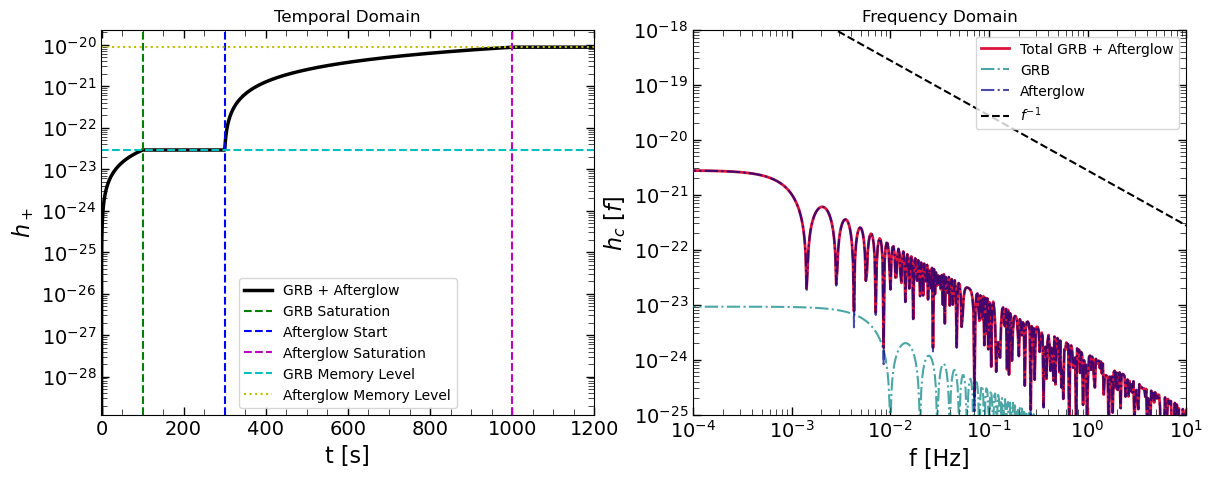

In [22]:
import utils_grb_aft_new as utils
import importlib
importlib.reload(utils)
t = np.linspace(-1, 1e4, 100000)
E_grb = 1e53 # erg
T_90 = 100
d = 100*1e6  # Mpc
beta = 0.99
theta = np.deg2rad(5)  # convert degrees to radians
theta_j = np.deg2rad(0.8)  # convert degrees to radians
E_aft = 3e55 # erg
t_dec = 300
t_jet_break = 1000
# Here I assumed that T_90 < t_dec < t_jet but it seems that the afterglow starts before the end of the prompt emission, check real value
f_obs = np.logspace(-5, 5, 1000)  

delta_h, delta_h_GRB, delta_h_aft = utils.grb_afterglow_model(t, E_grb, T_90, E_aft, beta, t_dec, t_jet_break, d, theta, theta_j)
H_total, H_GRB, H_aft = utils.fft(f_obs, delta_h_GRB, T_90, delta_h_aft, t_dec, t_jet_break)
fig, ax =utils.plot_grb_afterglow(t, delta_h, f_obs, H_total, H_GRB, H_aft, T_90, t_dec, t_jet_break, delta_h_GRB, delta_h_aft)
ax[1].set_xlim(1e-4, 1e1)
ax[1].set_ylim(1e-25, 1e-18)